# **FINAL COMPARISON — Best KNN Option vs CNN**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os
import joblib
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score,classification_report,
                             confusion_matrix,ConfusionMatrixDisplay,
                             precision_score,recall_score,f1_score)

## **Setting Paths**

In [4]:
PATH_KNN_A   = "/content/drive/MyDrive/Models/KNN_OptionA"
PATH_KNN_B   = "/content/drive/MyDrive/Models/KNN_OptionB"
PATH_KNN_C   = "/content/drive/MyDrive/Models/KNN_OptionC"
PATH_CNN     = "/content/drive/MyDrive/Models/CNN_Model/model.h5"
PATH_DATASET = "/content/drive/MyDrive/Dataset/A_Z Handwritten Data.csv"
PATH_OUTPUTS = "/content/drive/MyDrive/Models/FinalComparison"
os.makedirs(PATH_OUTPUTS, exist_ok=True)
SAMPLE_SIZE = 10_000
RANDOM_SEED = 42
LABELS_26   = [chr(65 + i) for i in range(26)]

## **Find & Load a file inside a folder**

In [5]:
def load_from_folder(folder, extensions=('.joblib', '.pkl', '.npy')):
    if not os.path.isdir(folder):
        raise FileNotFoundError(f"Folder not found: {folder}")
    for fname in sorted(os.listdir(folder)):
        fpath = os.path.join(folder, fname)
        ext   = os.path.splitext(fname)[1].lower()
        if ext in extensions:
            print(f"  Loading  {fpath}")
            if ext == '.npy':
                return np.load(fpath, allow_pickle=True).item(), fpath
            else:                          # .joblib or .pkl
                return joblib.load(fpath), fpath
    raise FileNotFoundError(
        f"No supported model file found in {folder}\n"
        f"Files present: {os.listdir(folder)}"
    )

## **Loading The Dataset**

In [6]:
print("Loading dataset ...")
data = pd.read_csv(PATH_DATASET).astype('float32')
data = data.groupby('0', group_keys=False).apply(
    lambda g: g.sample(min(len(g),SAMPLE_SIZE//26),random_state=RANDOM_SEED)
).reset_index(drop=True)
X_raw=data.drop('0',axis=1).values
y=data['0'].values.astype(int)
scaler= MinMaxScaler()
X_scaled=scaler.fit_transform(X_raw)
# Shared train/test split
X_train,X_test,y_train,y_test=train_test_split(
    X_scaled, y,test_size=0.2,random_state=RANDOM_SEED,stratify=y
)
print(f"Test set : {X_test.shape[0]} samples\n")

Loading dataset ...
Test set : 1997 samples



/tmp/ipykernel_1098/1540440949.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby('0', group_keys=False).apply(


## **Load the three KNN models & get predictions**

In [7]:
print("── Loading KNN models ──")
def get_predictions(folder, X_tr, y_tr, X_te):
    obj, fpath = load_from_folder(folder)
    # Case 1: saved fitted sklearn model
    if hasattr(obj, 'predict'):
        print(f"  Fitted model found — predicting directly.")
        return obj.predict(X_te), obj
    # Case 2: results dict saved by Option scripts
    if isinstance(obj, dict):
        print(f"  Results dict found. Keys: {list(obj.keys())}")
        if 'best_params' in obj:
            bp  = obj['best_params']
            knn = KNeighborsClassifier(
                n_neighbors = bp['k'],
                metric      = bp['metric'],
                weights     = bp['weights'],
                n_jobs      = -1
            )
        else:
            knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
        print(f"  Refitting KNN ...")
        knn.fit(X_tr, y_tr)
        return knn.predict(X_te), knn
    raise ValueError(f"Unrecognised object type in {folder}: {type(obj)}")
y_pred_A, _ = get_predictions(PATH_KNN_A, X_train, y_train, X_test)
y_pred_B, _ = get_predictions(PATH_KNN_B, X_train, y_train, X_test)
y_pred_C, _ = get_predictions(PATH_KNN_C, X_train, y_train, X_test)
acc_A = accuracy_score(y_test, y_pred_A)
acc_B = accuracy_score(y_test, y_pred_B)
acc_C = accuracy_score(y_test, y_pred_C)
print(f"\n  Option A — PSO              acc = {acc_A:.4f}")
print(f"  Option B — Grid Search      acc = {acc_B:.4f}")
print(f"  Option C — Preprocessing    acc = {acc_C:.4f}")
# Identify winner among KNN options
best_idx    = int(np.argmax([acc_A, acc_B, acc_C]))
best_labels = ['A — PSO', 'B — Grid Search', 'C — Preprocessing']
best_label  = best_labels[best_idx]
y_pred_best = [y_pred_A, y_pred_B, y_pred_C][best_idx]
acc_best    = [acc_A, acc_B, acc_C][best_idx]
print(f"\n  Best KNN : Option {best_label}  (acc = {acc_best:.4f})")
prec_knn = precision_score(y_test, y_pred_best, average='macro', zero_division=0)
rec_knn  = recall_score   (y_test, y_pred_best, average='macro', zero_division=0)
f1_knn   = f1_score       (y_test, y_pred_best, average='macro', zero_division=0)

── Loading KNN models ──
  Loading  /content/drive/MyDrive/Models/KNN_OptionA/results_A.npy
  Results dict found. Keys: ['option', 'accuracy', 'n_features', 'report']
  Refitting KNN ...
  Loading  /content/drive/MyDrive/Models/KNN_OptionB/results_B.npy
  Results dict found. Keys: ['option', 'accuracy', 'best_params', 'report']
  Refitting KNN ...
  Loading  /content/drive/MyDrive/Models/KNN_OptionC/results_C.npy
  Results dict found. Keys: ['option', 'accuracy', 'best_config', 'report']
  Refitting KNN ...

  Option A — PSO              acc = 0.8538
  Option B — Grid Search      acc = 0.8618
  Option C — Preprocessing    acc = 0.8538

  Best KNN : Option B — Grid Search  (acc = 0.8618)


## **Load & evaluate CNN**

In [8]:
print(f"\n── Loading CNN from {PATH_CNN} ──")
cnn_model = tf.keras.models.load_model(PATH_CNN)
cnn_model.summary()


── Loading CNN from /content/drive/MyDrive/Models/CNN_Model/model.h5 ──


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,180 (535.86 KB)

 Trainable params: 137,178 (535.85 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

## **Normalisation For The CNN From (N, 28, 28, 1) to [0, 1]**

In [9]:
X_cnn_test = X_test.reshape(-1, 28, 28, 1)
t0         = time.time()
y_prob_cnn = cnn_model.predict(X_cnn_test, verbose=1)
t_cnn      = time.time() - t0
y_pred_cnn = np.argmax(y_prob_cnn, axis=1)
acc_cnn  = accuracy_score(y_test, y_pred_cnn)
prec_cnn = precision_score(y_test, y_pred_cnn, average='macro', zero_division=0)
rec_cnn  = recall_score   (y_test, y_pred_cnn, average='macro', zero_division=0)
f1_cnn   = f1_score       (y_test, y_pred_cnn, average='macro', zero_division=0)
print(f"\n  CNN — Accuracy={acc_cnn:.4f}  Precision={prec_cnn:.4f}  "
      f"Recall={rec_cnn:.4f}  F1={f1_cnn:.4f}  ({t_cnn:.1f}s)")

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step

  CNN — Accuracy=0.9940  Precision=0.9941  Recall=0.9940  F1=0.9940  (3.5s)


## **Plot — Metrics bar chart**

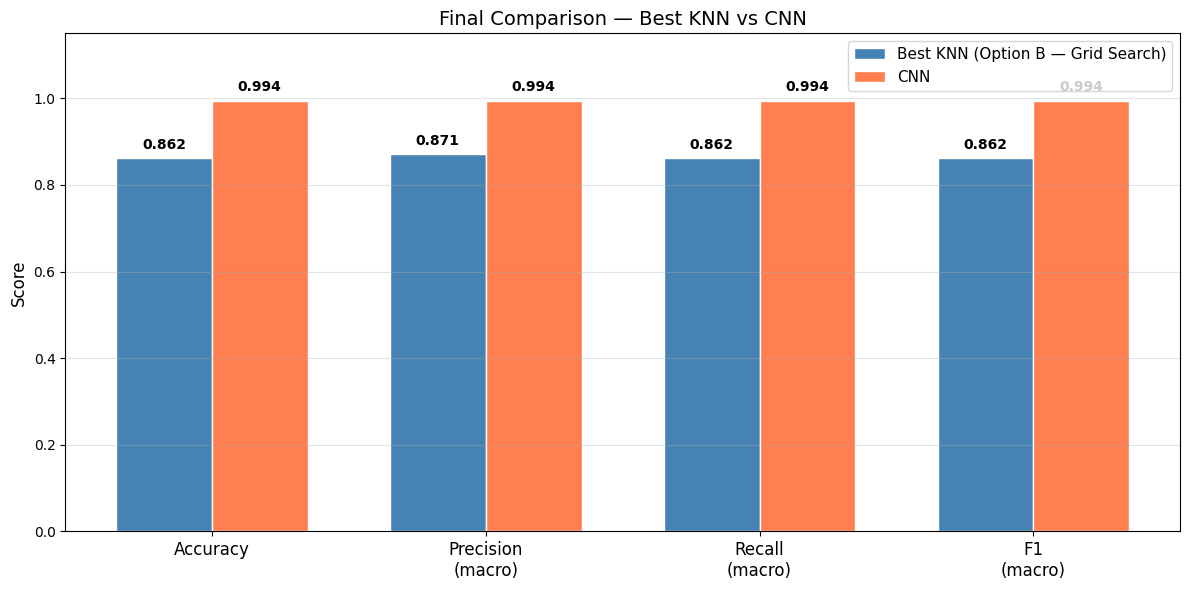

Saved -> /content/drive/MyDrive/Models/FinalComparison/plot1_metrics_comparison.png


In [10]:
metric_names = ['Accuracy', 'Precision\n(macro)', 'Recall\n(macro)', 'F1\n(macro)']
knn_vals     = [acc_best, prec_knn, rec_knn, f1_knn]
cnn_vals     = [acc_cnn,  prec_cnn, rec_cnn, f1_cnn]
x     = np.arange(len(metric_names))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - width/2, knn_vals, width,
            label=f'Best KNN (Option {best_label})',
            color='steelblue', edgecolor='white')
b2 = ax.bar(x + width/2, cnn_vals, width,
            label='CNN', color='coral', edgecolor='white')
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Final Comparison — Best KNN vs CNN", fontsize=14)
ax.set_xticks(x);  ax.set_xticklabels(metric_names, fontsize=12)
ax.legend(fontsize=11);  ax.grid(axis='y', alpha=0.35)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.015,
            f"{bar.get_height():.3f}",
            ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
out = os.path.join(PATH_OUTPUTS, "plot1_metrics_comparison.png")
plt.savefig(out, dpi=150);  plt.show()
print(f"Saved -> {out}")

## **Plot 2 — Radar chart**

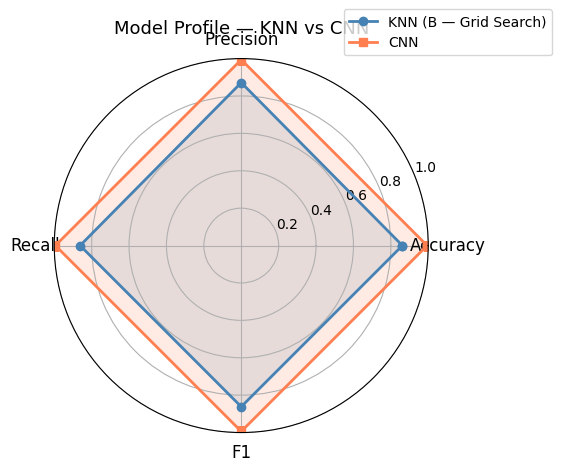

Saved -> /content/drive/MyDrive/Models/FinalComparison/plot5_radar_chart.png


In [12]:
categories = ['Accuracy', 'Precision', 'Recall', 'F1']
knn_r = [acc_best, prec_knn, rec_knn, f1_knn]
cnn_r = [acc_cnn,  prec_cnn, rec_cnn, f1_cnn]
N      = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
knn_r  += knn_r[:1]
cnn_r  += cnn_r[:1]
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, knn_r, 'o-', linewidth=2, color='steelblue',
        label=f'KNN ({best_label})')
ax.fill(angles, knn_r, alpha=0.15, color='steelblue')
ax.plot(angles, cnn_r, 's-', linewidth=2, color='coral', label='CNN')
ax.fill(angles, cnn_r, alpha=0.15, color='coral')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title("Model Profile — KNN vs CNN", fontsize=13, pad=18)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
out = os.path.join(PATH_OUTPUTS, "plot5_radar_chart.png")
plt.savefig(out, dpi=150, bbox_inches='tight');  plt.show()
print(f"Saved -> {out}")

### **Final Report**

In [11]:
SEP = "=" * 65
print(f"\n{SEP}")
print("  FINAL COMPARISON REPORT")
print(SEP)
print(f"  {'Model':<35} {'Accuracy':>8}  {'Precision':>9}  {'Recall':>7}  {'F1':>7}")
print("  " + "-" * 60)
print(f"  {'KNN Option A  — PSO':<35} {acc_A:>8.4f}")
print(f"  {'KNN Option B  — Grid Search':<35} {acc_B:>8.4f}")
print(f"  {'KNN Option C  — Preprocessing':<35} {acc_C:>8.4f}")
print("  " + "-" * 60)
print(f"  {'Best KNN  (Option ' + best_label + ')':<35} "
      f"{acc_best:>8.4f}  {prec_knn:>9.4f}  {rec_knn:>7.4f}  {f1_knn:>7.4f}")
print(f"  {'CNN':<35} "
      f"{acc_cnn:>8.4f}  {prec_cnn:>9.4f}  {rec_cnn:>7.4f}  {f1_cnn:>7.4f}")
print(SEP)
winner = "CNN" if acc_cnn > acc_best else f"KNN Option {best_label}"
margin = abs(acc_cnn - acc_best) * 100
print(f"\n  Trophy  Winner : {winner}  (margin +{margin:.2f}%)")
print(SEP)
print(f"\nAll plots saved to -> {PATH_OUTPUTS}")


  FINAL COMPARISON REPORT
  Model                               Accuracy  Precision   Recall       F1
  ------------------------------------------------------------
  KNN Option A  — PSO                   0.8538
  KNN Option B  — Grid Search           0.8618
  KNN Option C  — Preprocessing         0.8538
  ------------------------------------------------------------
  Best KNN  (Option B — Grid Search)    0.8618     0.8714   0.8618   0.8619
  CNN                                   0.9940     0.9941   0.9940   0.9940

  Trophy  Winner : CNN  (margin +13.22%)

All plots saved to -> /content/drive/MyDrive/Models/FinalComparison
